## Pymc

In [1]:
import jax
import jax.numpy as jnp
from jax import lax
import numpy as np
import matplotlib.pyplot as plt

# NOTE: TensorFlow Probability JAX substrate is incompatible with recent JAX (>=0.7).
# To keep this notebook runnable on modern Colab/JAX, we implement the tiny subset we need
# (Beta and Bernoulli with .prob(), .log_prob(), and Beta's concentration params) using JAX+SciPy special functions.

import jax.scipy.stats as jstats
import jax.scipy.special as jsps
import jax.random as jr

class BetaDist:
    def __init__(self, concentration1, concentration0, eps=1e-12):
        self.concentration1 = concentration1
        self.concentration0 = concentration0
        self._eps = eps

    def prob(self, x):
        return jstats.beta.pdf(x, self.concentration1, self.concentration0)

    def log_prob(self, x):
        return jstats.beta.logpdf(x, self.concentration1, self.concentration0)

    def sample(self, key, sample_shape=()):
        # Beta(a,b) = Gamma(a,1) / (Gamma(a,1) + Gamma(b,1))
        k1, k2 = jr.split(key, 2)
        g1 = jr.gamma(k1, self.concentration1, shape=sample_shape)
        g2 = jr.gamma(k2, self.concentration0, shape=sample_shape)
        return g1 / (g1 + g2 + self._eps)

class BernoulliDist:
    def __init__(self, probs, eps=1e-12):
        self.probs = jnp.clip(probs, eps, 1 - eps)

    def prob(self, y):
        y = jnp.asarray(y)
        return self.probs**y * (1 - self.probs)**(1 - y)

    def log_prob(self, y):
        y = jnp.asarray(y)
        return y * jnp.log(self.probs) + (1 - y) * jnp.log(1 - self.probs)

import pymc as pm
import scipy.stats as stats
import scipy.special as sp
import arviz as az

import math

In [5]:
# Use same data as https://github.com/probml/probml-notebooks/blob/main/notebooks/beta_binom_approx_post_pymc.ipynb
key = jax.random.PRNGKey(128)
dataset = np.repeat([0, 1], (10, 1))
n_samples = len(dataset)
print(f"Dataset: {dataset}")
n_heads = dataset.sum()
n_tails = n_samples - n_heads

Dataset: [0 0 0 0 0 0 0 0 0 0 1]


In [6]:
# prior distribution ~ Beta
def prior_dist():
    return BetaDist(concentration1=1.0, concentration0=1.0)

# likelihood distribution ~ Bernoulli
def likelihood_dist(theta):
    return BernoulliDist(probs=theta)

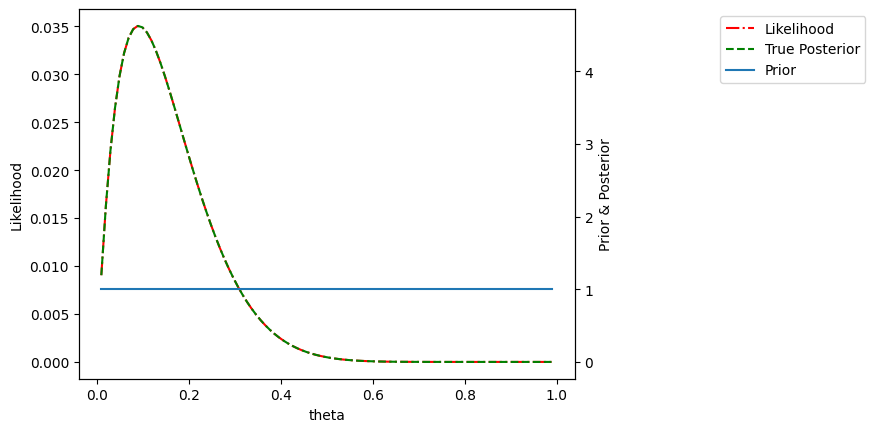

In [7]:
# closed form of beta posterior
a = prior_dist().concentration1
b = prior_dist().concentration0

exact_posterior = BetaDist(concentration1=a + n_heads, concentration0=b + n_tails)

theta_range = jnp.linspace(0.01, 0.99, 100)

ax = plt.gca()
ax2 = ax.twinx()
(plt2,) = ax2.plot(theta_range, exact_posterior.prob(theta_range), "g--", label="True Posterior")
(plt3,) = ax2.plot(theta_range, prior_dist().prob(theta_range), label="Prior")

likelihood = jax.vmap(lambda x: jnp.prod(likelihood_dist(x).prob(dataset)))(theta_range)
(plt1,) = ax.plot(theta_range, likelihood, "r-.", label="Likelihood")

ax.set_xlabel("theta")
ax.set_ylabel("Likelihood")
ax2.set_ylabel("Prior & Posterior")
ax2.legend(handles=[plt1, plt2, plt3], bbox_to_anchor=(1.6, 1));

In [ ]:
# Laplace

"""
with pm.Model() as normal_aproximation:
    theta = pm.Beta("theta", 1.0, 1.0)
    y = pm.Binomial("y", n=1, p=theta, observed=dataset)  # Bernoulli
    mean_q = pm.find_MAP()
    std_q = ((1 / pm.find_hessian(mean_q, vars=[theta])) ** 0.5)[0]
    print(theta)
    print(pm.find_hessian(mean_q, vars=[theta]))
    loc = mean_q["theta"]
"""

"""
pm.find_hessian() returns the local curvature of the log-posterior at the MAP, not a standard deviation.
For a Laplace (Gaussian) approximation you need a variance/covariance,
which comes from the inverse curvature (with the right sign convention),
and for Beta you also have to respect the parameter constraint/transform.
So taking 1 / find_hessian and square-rooting it is not a reliable way to get std_q,
and can even give invalid values depending on the sign.
"""

Output()

/usr/local/lib/python3.12/dist-packages/pytensor/configparser.py:44: FutureWarning: hessian will stop negating the output in a future version of PyMC.
To suppress this warning set `negate_output=False`
  return f(*args, **kwargs)


theta


/usr/local/lib/python3.12/dist-packages/pytensor/configparser.py:44: FutureWarning: hessian will stop negating the output in a future version of PyMC.
To suppress this warning set `negate_output=False`
  return f(*args, **kwargs)


[[1.0743802]]


## Beta–Bernoulli (closed form)

### Model
$$
\theta \sim \mathrm{Beta}(\alpha_0,\beta_0)
$$

$$
y_i \mid \theta \sim \mathrm{Bernoulli}(\theta),\quad i=1,\dots,n
$$

Let
$$
n_1=\sum_{i=1}^n y_i,\qquad n_0=n-n_1
$$

### Likelihood
$$
p(\mathbf y\mid \theta)=\theta^{n_1}(1-\theta)^{n_0}
$$

### Posterior (closed form)
$$
p(\theta\mid \mathbf y)\propto \theta^{\alpha_0-1+n_1}(1-\theta)^{\beta_0-1+n_0}
$$

Hence
$$
\theta\mid \mathbf y \sim \mathrm{Beta}(\alpha_{\text{post}},\beta_{\text{post}})
$$

with
$$
\alpha_{\text{post}}=\alpha_0+n_1,\qquad \beta_{\text{post}}=\beta_0+n_0
$$

### MAP (mode)
If $\alpha_{\text{post}}>1$ and $\beta_{\text{post}}>1$,
$$
\theta_{\text{MAP}}=\frac{\alpha_{\text{post}}-1}{\alpha_{\text{post}}+\beta_{\text{post}}-2}
$$

### Laplace ingredients in $\theta$-space (for comparison)
Ignoring constants,
$$
\log p(\theta\mid \mathbf y)
=
(\alpha_{\text{post}}-1)\log\theta + (\beta_{\text{post}}-1)\log(1-\theta)+C
$$

$$
\frac{d^2}{d\theta^2}\log p(\theta\mid \mathbf y)
=
-\frac{\alpha_{\text{post}}-1}{\theta^2}
-\frac{\beta_{\text{post}}-1}{(1-\theta)^2}
$$

Laplace variance at $\theta_{\text{MAP}}$:
$$
\sigma^2_{\text{Lap}}
=
\left(
-\left.\frac{d^2}{d\theta^2}\log p(\theta\mid \mathbf y)\right|_{\theta=\theta_{\text{MAP}}}
\right)^{-1}
$$


In [9]:

with pm.Model() as normal_aproximation:
    theta = pm.Beta("theta", 1.0, 1.0)
    y = pm.Binomial("y", n=1, p=theta, observed=dataset)  # Bernoulli

    mean_q = pm.find_MAP()                # keep teacher's MAP
    loc = float(mean_q["theta"])          # keep MAP as the Laplace mean

    data = np.asarray(dataset).astype(int).ravel()
    n_heads = int(data.sum())
    n_tails = int(len(data) - n_heads)

    a_post = 1.0 + n_heads
    b_post = 1.0 + n_tails

    # d2/dθ2 log p(θ|D) at θ=loc (negative)
    H_theta = -(a_post - 1) / (loc**2) - (b_post - 1) / ((1 - loc)**2)

    # Laplace variance = 1 / (-H)
    std_q = float(np.sqrt(1.0 / (-H_theta)))

    # keep your prints (but print the PyMC Hessian just for reference)
    print(theta)
    print("PyMC find_hessian =", pm.find_hessian(mean_q, vars=[theta]))
    print("theta-space std_q =", std_q)

Output()

theta


/usr/local/lib/python3.12/dist-packages/pytensor/configparser.py:44: FutureWarning: hessian will stop negating the output in a future version of PyMC.
To suppress this warning set `negate_output=False`
  return f(*args, **kwargs)


PyMC find_hessian = [[1.0743802]]
theta-space std_q = 0.0866784202419563


In [ ]:
loc, std_q, mean_q

(0.09090909444918384,
 0.0866784202419563,
 {'theta_logodds__': array(-2.30258505), 'theta': array(0.09090909)})

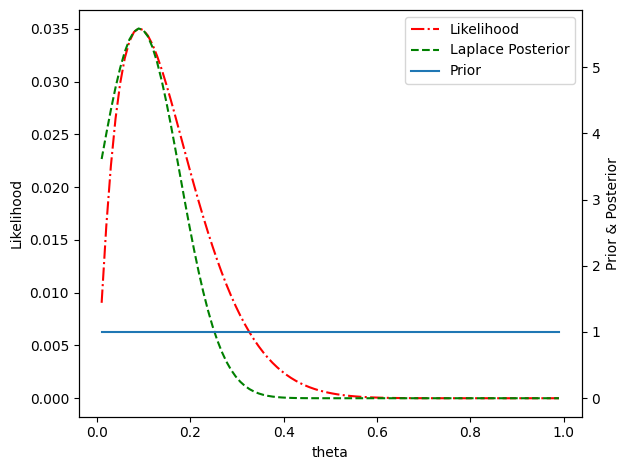

In [17]:
theta_range = jnp.linspace(0.01, 0.99, 100)

ax = plt.gca()
ax2 = ax.twinx()

x_np = np.array(theta_range)
laplace_pdf = stats.norm.pdf(x_np, loc=float(loc), scale=float(std_q))
laplace_pdf = laplace_pdf / np.trapezoid(laplace_pdf, x_np)  # optional renorm on [0,1]
(plt2,) = ax2.plot(theta_range, laplace_pdf, "g--", label="Laplace Posterior")

# keep prior exactly as demo
(plt3,) = ax2.plot(theta_range, prior_dist().prob(theta_range), label="Prior")

# keep likelihood exactly as demo (use x)
likelihood = jax.vmap(lambda x: jnp.prod(likelihood_dist(x).prob(dataset)))(theta_range)
(plt1,) = ax.plot(theta_range, likelihood, "r-.", label="Likelihood")

ax.set_xlabel("theta")
ax.set_ylabel("Likelihood")
ax2.set_ylabel("Prior & Posterior")
ax2.legend(handles=[plt1, plt2, plt3])
plt.tight_layout()
plt.show()


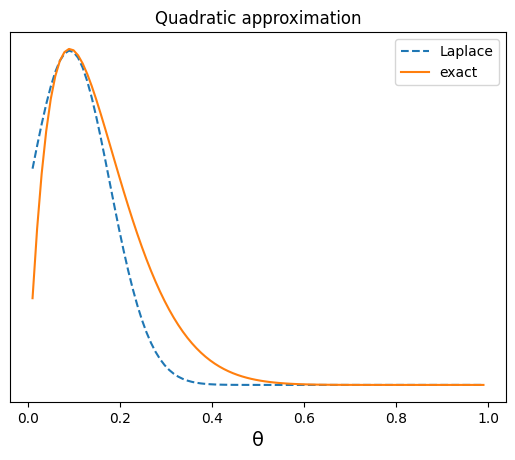

In [ ]:
x = theta_range

plt.figure()
plt.plot(x, stats.norm.pdf(x, loc, std_q), "--", label="Laplace")
post_exact = stats.beta.pdf(x, n_heads + 1, n_tails + 1)
plt.plot(x, post_exact, label="exact")
plt.title("Quadratic approximation")
plt.xlabel("θ", fontsize=14)
plt.yticks([])
plt.legend()